## Import Packages

In [ ]:
# Import packages
import pandas as pd
import numpy as np
import statsmodels as sm
import pylab as pl
from scipy import stats
from sklearn import preprocessing
from sklearn import cluster, tree, decomposition
import matplotlib.pyplot as plt
import pydot
import seaborn as sns

pd.set_option('display.max_columns', None)

## Loading the Data

In [16]:
travel = pd.read_csv('../data/clustering/travel.csv', parse_dates=['date_time','srch_ci','srch_co'])

In [17]:
travel.head()

,date_time,site_name,posa_continent,user_location_country,user_location_region,user_location_city,orig_destination_distance,user_id,is_mobile,is_package,channel,srch_ci,srch_co,srch_adults_cnt,srch_children_cnt,srch_rm_cnt,srch_destination_id,srch_destination_type_id,is_booking,cnt,hotel_continent,hotel_country,hotel_market,hotel_cluster
0,2014-11-03 16:02:00,24,2,77,871,36643,456.1151,792280,0,1,1,2014-12-15,2014-12-19,2,0,1,8286,1,0,1,0,63,1258,68
1,2013-03-13 19:25:00,11,3,205,135,38749,232.4737,961995,0,0,9,2013-03-13,2013-03-14,2,0,1,1842,3,0,1,2,198,786,37
2,2014-10-13 13:20:00,2,3,66,314,48562,4468.2720,495669,0,1,9,2015-04-03,2015-04-10,2,0,1,8746,1,0,1,6,105,29,22
3,2013-11-05 10:40:00,11,3,205,411,52752,171.6021,106611,0,0,0,2013-11-07,2013-11-08,2,0,1,6210,3,1,1,2,198,1234,42
4,2014-06-10 13:34:00,2,3,66,174,50644,NaN,596177,0,0,9,2014-08-03,2014-08-08,2,1,1,12812,5,0,1,2,50,368,83


In [18]:
travel.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 24 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   date_time                  100000 non-null  datetime64[us]
 1   site_name                  100000 non-null  int64         
 2   posa_continent             100000 non-null  int64         
 3   user_location_country      100000 non-null  int64         
 4   user_location_region       100000 non-null  int64         
 5   user_location_city         100000 non-null  int64         
 6   orig_destination_distance  63915 non-null   float64       
 7   user_id                    100000 non-null  int64         
 8   is_mobile                  100000 non-null  int64         
 9   is_package                 100000 non-null  int64         
 10  channel                    100000 non-null  int64         
 11  srch_ci                    99878 non-null   datetime64[us]
 12  

In [9]:
travel.isnull().sum()

date_time                        0
site_name                        0
posa_continent                   0
user_location_country            0
user_location_region             0
user_location_city               0
orig_destination_distance    36085
user_id                          0
is_mobile                        0
is_package                       0
channel                          0
srch_ci                        122
srch_co                        122
srch_adults_cnt                  0
srch_children_cnt                0
srch_rm_cnt                      0
srch_destination_id              0
srch_destination_type_id         0
is_booking                       0
cnt                              0
hotel_continent                  0
hotel_country                    0
hotel_market                     0
hotel_cluster                    0
dtype: int64

## Correlation Analysis

In [20]:
corr = travel.corr()
corr

,date_time,site_name,posa_continent,user_location_country,user_location_region,user_location_city,orig_destination_distance,user_id,is_mobile,is_package,channel,srch_ci,srch_co,srch_adults_cnt,srch_children_cnt,srch_rm_cnt,srch_destination_id,srch_destination_type_id,is_booking,cnt,hotel_continent,hotel_country,hotel_market,hotel_cluster
date_time,1.000000,-0.024018,-0.010503,-0.021281,-0.012536,-0.004335,-0.002967,-0.017718,0.023642,-0.001773,-0.059976,0.952221,0.951117,0.013011,-0.075139,-0.004368,0.011650,-0.040562,-0.032699,-0.089140,-0.008460,-0.005722,0.003028,-0.000059
site_name,-0.024018,1.000000,-0.637743,0.159283,0.130818,-0.013471,0.027609,0.030404,-0.005418,0.048820,-0.027780,-0.001569,-0.001054,-0.013405,-0.031962,0.016585,0.034895,-0.006934,-0.013460,0.022274,0.201760,0.263167,-0.068316,-0.026689
posa_continent,-0.010503,-0.637743,1.000000,0.179726,-0.034647,0.039227,0.049808,-0.015209,0.016331,-0.093459,0.089680,-0.026851,-0.027669,0.012350,0.034453,-0.033712,-0.015535,0.037172,0.013319,-0.018952,-0.333578,-0.156578,0.049214,0.018297
user_location_country,-0.021281,0.159283,0.179726,1.000000,0.058496,0.122686,0.047689,-0.021091,0.003728,-0.025284,0.109999,-0.020851,-0.020539,0.042526,0.037101,0.000858,0.013486,0.028888,0.001284,0.003539,-0.063744,0.097624,0.015569,-0.011876
user_location_region,-0.012536,0.130818,-0.034647,0.058496,1.000000,0.132457,0.136560,0.002225,0.016982,0.040482,-0.001600,0.009723,0.010378,0.005487,0.014009,0.000254,0.022567,0.001376,0.000253,-0.007570,0.043027,-0.050301,0.040367,0.004984
user_location_city,-0.004335,-0.013471,0.039227,0.122686,0.132457,1.000000,0.014178,-0.007989,-0.003741,0.013032,0.023497,-0.004184,-0.003894,0.006628,0.002638,-0.000694,0.000786,-0.004399,-0.002655,-0.002175,0.007759,-0.001987,0.008558,0.000102
orig_destination_distance,-0.002967,0.027609,0.049808,0.047689,0.136560,0.014178,1.000000,0.017015,-0.059464,0.041991,-0.000398,0.080935,0.083821,-0.024039,-0.059722,-0.012484,-0.036314,-0.042859,-0.033480,0.009483,0.416180,0.254321,-0.090112,0.003624
user_id,-0.017718,0.030404,-0.015209,-0.021091,0.002225,-0.007989,0.017015,1.000000,-0.011439,-0.018901,-0.003593,-0.014944,-0.014900,-0.007370,0.002983,-0.001625,0.002716,0.007133,0.001561,0.001355,0.002447,0.008707,-0.002463,0.003202
is_mobile,0.023642,-0.005418,0.016331,0.003728,0.016982,-0.003741,-0.059464,-0.011439,1.000000,0.046903,-0.030770,0.024625,0.024727,0.016661,0.018211,-0.022565,-0.007140,-0.016039,-0.028623,0.008084,-0.024144,-0.029574,0.007644,0.012145
is_package,-0.001773,0.048820,-0.093459,-0.025284,0.040482,0.013032,0.041991,-0.018901,0.046903,1.000000,-0.011269,0.057690,0.061811,-0.024097,-0.037673,-0.036653,-0.146647,-0.224422,-0.081307,0.126500,0.108993,-0.044426,-0.014636,0.031399


<Axes: >

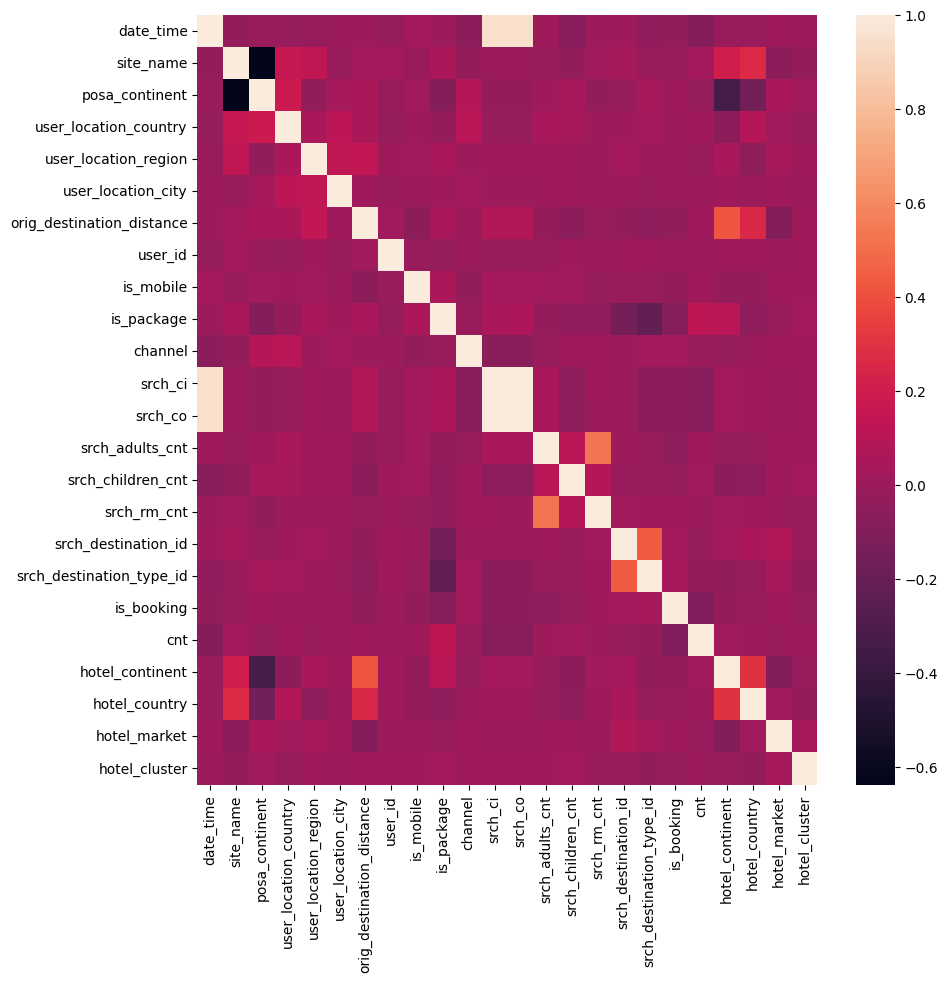

In [21]:
plt.figure(figsize=(10,10))

sns.heatmap(corr)

In [22]:
travel.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 24 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   date_time                  100000 non-null  datetime64[us]
 1   site_name                  100000 non-null  int64         
 2   posa_continent             100000 non-null  int64         
 3   user_location_country      100000 non-null  int64         
 4   user_location_region       100000 non-null  int64         
 5   user_location_city         100000 non-null  int64         
 6   orig_destination_distance  63915 non-null   float64       
 7   user_id                    100000 non-null  int64         
 8   is_mobile                  100000 non-null  int64         
 9   is_package                 100000 non-null  int64         
 10  channel                    100000 non-null  int64         
 11  srch_ci                    99878 non-null   datetime64[us]
 12  

## Destributions

array([[<Axes: title={'center': 'channel'}>,
        <Axes: title={'center': 'is_booking'}>,
        <Axes: title={'center': 'is_mobile'}>],
       [<Axes: title={'center': 'orig_destination_distance'}>,
        <Axes: title={'center': 'srch_children_cnt'}>,
        <Axes: title={'center': 'srch_adults_cnt'}>],
       [<Axes: title={'center': 'srch_rm_cnt'}>, <Axes: >, <Axes: >]],
      dtype=object)

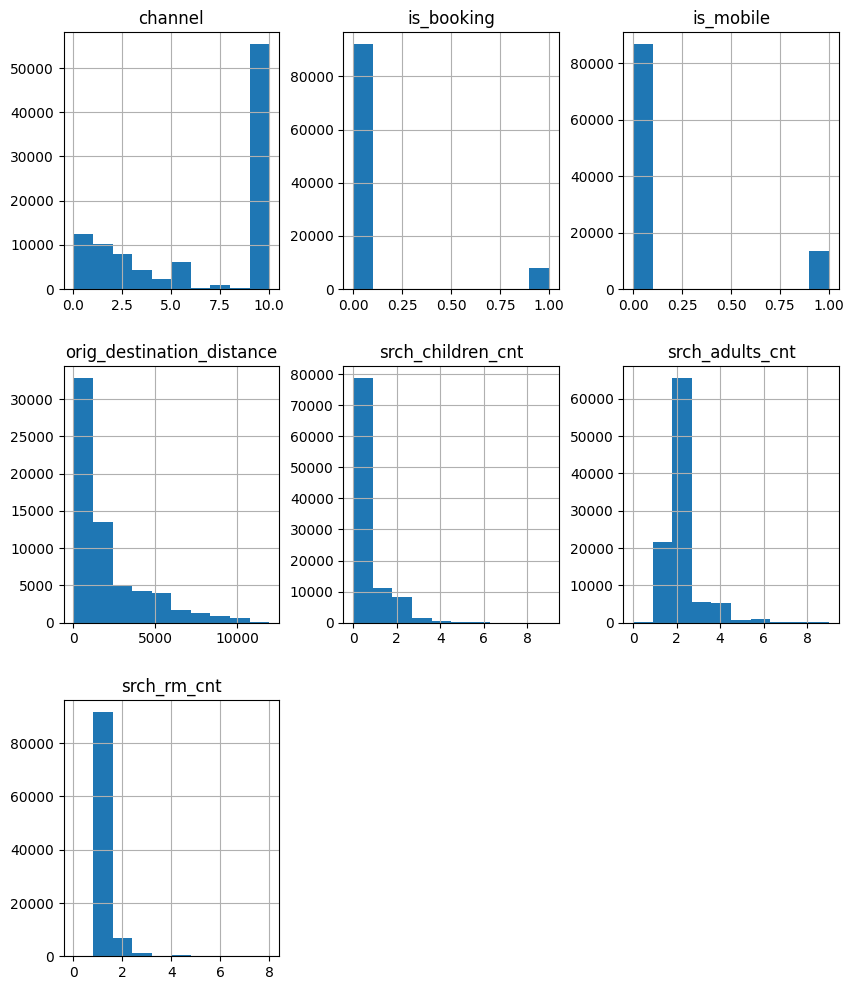

In [24]:
columns = ['channel','is_booking', 'is_mobile', 'orig_destination_distance','srch_children_cnt','srch_adults_cnt','srch_rm_cnt']

travel[columns].hist(figsize=(10,12))

## Booking Exploration

In [29]:
booking_count_per_user = travel.groupby('user_id')['is_booking'].agg(number_of_bookings = 'count').reset_index()

booking_count_per_user.groupby('number_of_bookings')['user_id'].agg('count')

number_of_bookings
1    79189
2     8423
3     1065
4      161
5       24
6        1
Name: user_id, dtype: int64

array([[<Axes: title={'center': 'number_of_bookings'}>]], dtype=object)

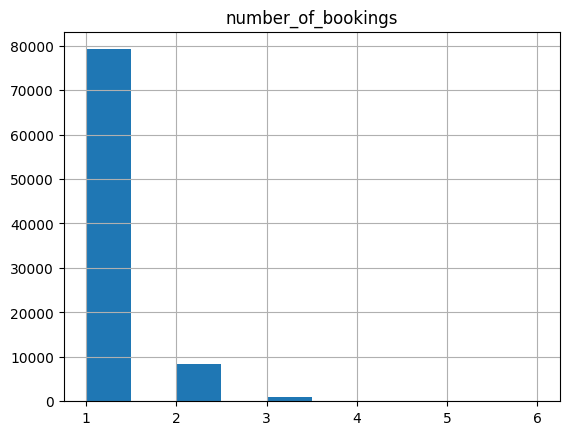

In [31]:
booking_count_per_user[['number_of_bookings']].hist()

In [32]:
# Exploriing Hranush's suggeestion

## Logical Checks

In [33]:
pd.crosstab(travel['srch_adults_cnt'],travel['srch_children_cnt'])

srch_children_cnt,0,1,2,3,4,5,6,7,8,9
srch_adults_cnt,,,,,,,,,,
0,174,2,3,2,0,0,0,0,0,0
1,18749,2137,523,117,11,1,9,1,2,0
2,50736,7093,6529,972,208,14,7,1,0,0
3,3645,1131,469,131,27,5,2,2,0,2
4,3933,690,494,77,83,9,4,0,0,0
5,535,131,41,20,6,4,2,0,0,0
6,669,73,53,28,18,13,7,0,0,0
7,99,20,5,8,6,3,0,0,0,0
8,183,12,13,2,6,1,3,2,2,1


In [40]:
travel[(travel['srch_adults_cnt']==0) & (travel['srch_children_cnt']==0)].head()

,date_time,site_name,posa_continent,user_location_country,user_location_region,user_location_city,orig_destination_distance,user_id,is_mobile,is_package,channel,srch_ci,srch_co,srch_adults_cnt,srch_children_cnt,srch_rm_cnt,srch_destination_id,srch_destination_type_id,is_booking,cnt,hotel_continent,hotel_country,hotel_market,hotel_cluster
115,2014-10-07 14:43:00,2,3,66,293,52284,NaN,909952,0,1,9,2015-01-10,2015-01-15,0,0,1,8250,1,0,1,2,50,628,1
496,2013-06-15 19:12:00,29,1,52,40,29080,NaN,150434,0,1,9,2013-09-16,2013-09-20,0,0,2,25408,6,0,2,6,15,1534,46
1261,2014-10-26 10:20:00,2,3,66,220,22648,5148.4830,588617,1,1,2,2015-08-24,2015-09-03,0,0,1,8746,1,0,1,6,105,29,78
1428,2014-11-16 10:21:00,2,3,66,174,53801,1638.7472,207522,1,1,0,2015-04-18,2015-04-25,0,0,1,8810,1,0,1,4,8,1532,52
1539,2014-12-28 19:16:00,2,3,66,363,31138,1526.8518,938404,0,1,0,NaT,NaT,0,0,1,8277,1,0,1,2,50,412,9


In [ ]:
# Once we see that it is working we can inplace it in the next chunk
travel.drop(travel[travel['srch_adults_cnt'] + travel['srch_children_cnt']==0].index).shape
# travel.shape

(99826, 24)

In [44]:
travel.drop(travel[travel['srch_adults_cnt'] + travel['srch_children_cnt']==0].index, inplace=True)

In [45]:
travel.info()

<class 'pandas.DataFrame'>
Index: 99826 entries, 0 to 99999
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   date_time                  99826 non-null  datetime64[us]
 1   site_name                  99826 non-null  int64         
 2   posa_continent             99826 non-null  int64         
 3   user_location_country      99826 non-null  int64         
 4   user_location_region       99826 non-null  int64         
 5   user_location_city         99826 non-null  int64         
 6   orig_destination_distance  63800 non-null  float64       
 7   user_id                    99826 non-null  int64         
 8   is_mobile                  99826 non-null  int64         
 9   is_package                 99826 non-null  int64         
 10  channel                    99826 non-null  int64         
 11  srch_ci                    99705 non-null  datetime64[us]
 12  srch_co             

In [49]:
travel[['date_time','srch_ci','srch_co']].head()

,date_time,srch_ci,srch_co
0,2014-11-03 16:02:00,2014-12-15,2014-12-19
1,2013-03-13 19:25:00,2013-03-13,2013-03-14
2,2014-10-13 13:20:00,2015-04-03,2015-04-10
3,2013-11-05 10:40:00,2013-11-07,2013-11-08
4,2014-06-10 13:34:00,2014-08-03,2014-08-08


In [48]:
travel['date'] = pd.to_datetime(travel['date_time'].apply(lambda x: x.date()))
travel.head(2)

,date_time,site_name,posa_continent,user_location_country,user_location_region,user_location_city,orig_destination_distance,user_id,is_mobile,is_package,channel,srch_ci,srch_co,srch_adults_cnt,srch_children_cnt,srch_rm_cnt,srch_destination_id,srch_destination_type_id,is_booking,cnt,hotel_continent,hotel_country,hotel_market,hotel_cluster,date
0,2014-11-03 16:02:00,24,2,77,871,36643,456.1151,792280,0,1,1,2014-12-15,2014-12-19,2,0,1,8286,1,0,1,0,63,1258,68,2014-11-03
1,2013-03-13 19:25:00,11,3,205,135,38749,232.4737,961995,0,0,9,2013-03-13,2013-03-14,2,0,1,1842,3,0,1,2,198,786,37,2013-03-13


In [52]:
travel.shape

(99826, 25)

In [55]:
travel[travel['date']<=travel['srch_ci']].shape

travel[travel['srch_ci']<=travel['srch_co']].shape

(99703, 25)

## Feature Egnineering

`duration`

`days_in_advanced`

In [56]:
def duration(row, start,end):
    delta = (row[end] - row[start])/np.timedelta64(1,'D')

    if delta<=0:
        return np.nan
    else:
        return delta

### Duration 

In [58]:
travel['duration'] = travel.apply(duration, args=('srch_ci','srch_co'), axis=1)

travel['duration'].mean()

np.float64(3.38388892804285)

### Days In advanced

In [60]:
travel['days_in_advanced'] = travel.apply(duration, args=('date','srch_ci'), axis=1)

travel['days_in_advanced'].mean()

np.float64(56.85852947561013)

In [65]:
travel.groupby('channel')['is_booking'].agg(booking_rate = 'mean',num_of_bookings = 'count').reset_index().sort_values(by = 'num_of_bookings', ascending=False)

,channel,booking_rate,num_of_bookings
9,9,0.085365,55280
0,0,0.072184,12482
1,1,0.069568,10249
2,2,0.060583,7824
5,5,0.094533,6146
3,3,0.060482,4398
4,4,0.120438,2192
7,7,0.043263,809
8,8,0.051852,270
6,6,0.068323,161


In [66]:
travel.groupby('channel')['is_booking'].agg(booking_rate = 'mean',num_of_bookings = 'count').reset_index().sort_values(by = 'booking_rate', ascending=False)

,channel,booking_rate,num_of_bookings
10,10,0.200000,15
4,4,0.120438,2192
5,5,0.094533,6146
9,9,0.085365,55280
0,0,0.072184,12482
1,1,0.069568,10249
6,6,0.068323,161
2,2,0.060583,7824
3,3,0.060482,4398
8,8,0.051852,270


In [67]:
travel.info()

<class 'pandas.DataFrame'>
Index: 99826 entries, 0 to 99999
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   date_time                  99826 non-null  datetime64[us]
 1   site_name                  99826 non-null  int64         
 2   posa_continent             99826 non-null  int64         
 3   user_location_country      99826 non-null  int64         
 4   user_location_region       99826 non-null  int64         
 5   user_location_city         99826 non-null  int64         
 6   orig_destination_distance  63800 non-null  float64       
 7   user_id                    99826 non-null  int64         
 8   is_mobile                  99826 non-null  int64         
 9   is_package                 99826 non-null  int64         
 10  channel                    99826 non-null  int64         
 11  srch_ci                    99705 non-null  datetime64[us]
 12  srch_co             

## Clustering

### Step 1: Feature Selection

In [69]:
features_to_explore = ['duration','days_in_advanced', 'orig_destination_distance','is_mobile','srch_adults_cnt','srch_children_cnt', 'srch_rm_cnt']

In [71]:
df_clustering = travel[features_to_explore].dropna(axis=0)

df_clustering.head()



,duration,days_in_advanced,orig_destination_distance,is_mobile,srch_adults_cnt,srch_children_cnt,srch_rm_cnt
0,4.0,42.0,456.1151,0,2,0,1
2,7.0,172.0,4468.2720,0,2,0,1
3,1.0,2.0,171.6021,0,2,0,1
6,2.0,30.0,329.1833,0,2,0,1
9,2.0,55.0,2284.9105,0,2,1,1


In [72]:
df_clustering.shape

(61312, 7)

$$c^2 = a^2+b^2$$

### Step 2: Standardizing our date

In [75]:
df_clustering_stg = df_clustering.copy()

df_clustering_stg[features_to_explore] = preprocessing.scale(df_clustering_stg[features_to_explore])

In [76]:
df_clustering_stg.head()

,duration,days_in_advanced,orig_destination_distance,is_mobile,srch_adults_cnt,srch_children_cnt,srch_rm_cnt
0,0.221476,-0.203700,-0.692681,-0.387793,-0.05231,-0.471193,-0.242802
2,1.230778,1.796806,1.095087,-0.387793,-0.05231,-0.471193,-0.242802
3,-0.787826,-0.819240,-0.819456,-0.387793,-0.05231,-0.471193,-0.242802
6,-0.451392,-0.388362,-0.749240,-0.387793,-0.05231,-0.471193,-0.242802
9,-0.451392,-0.003649,0.122208,-0.387793,-0.05231,0.840428,-0.242802


### Step 3: K-means k= 3

In [80]:
km = cluster.KMeans(n_clusters=3, max_iter=300, random_state=123)

df_clustering_stg['cluster'] = km.fit_predict(df_clustering_stg[features_to_explore])

In [82]:
df_clustering_stg

,duration,days_in_advanced,orig_destination_distance,is_mobile,srch_adults_cnt,srch_children_cnt,srch_rm_cnt,cluster
0,0.221476,-0.203700,-0.692681,-0.387793,-0.052310,-0.471193,-0.242802,2
2,1.230778,1.796806,1.095087,-0.387793,-0.052310,-0.471193,-0.242802,1
3,-0.787826,-0.819240,-0.819456,-0.387793,-0.052310,-0.471193,-0.242802,2
6,-0.451392,-0.388362,-0.749240,-0.387793,-0.052310,-0.471193,-0.242802,2
9,-0.451392,-0.003649,0.122208,-0.387793,-0.052310,0.840428,-0.242802,2
...,...,...,...,...,...,...,...,...
99993,-0.787826,-0.696132,-0.731701,-0.387793,-1.171765,-0.471193,-0.242802,2
99995,0.221476,0.642668,-0.278154,-0.387793,-0.052310,-0.471193,-0.242802,2
99996,-0.787826,-0.834628,-0.584838,-0.387793,-1.171765,-0.471193,-0.242802,2
99998,-0.451392,-0.680743,-0.803570,-0.387793,-0.052310,-0.471193,-0.242802,2


In [81]:
df_clustering_stg['cluster'].value_counts()

cluster
2    35835
1    15998
0     9479
Name: count, dtype: int64

### Pricipal Component Analysis

In [85]:
pca = decomposition.PCA(n_components=2,whiten=True)

df_clustering_stg['x'] = pca.fit_transform(df_clustering_stg[features_to_explore])[:,0]
df_clustering_stg['y'] = pca.fit_transform(df_clustering_stg[features_to_explore])[:,1]



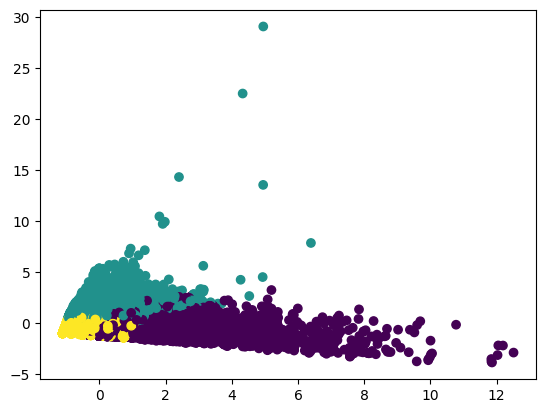

In [86]:
plt.scatter(df_clustering_stg['x'],df_clustering_stg['y'], c =df_clustering_stg['cluster'])
plt.show()


In [91]:
df_clustering.head()


df_clustering_stg.head()

,duration,days_in_advanced,orig_destination_distance,is_mobile,srch_adults_cnt,srch_children_cnt,srch_rm_cnt,cluster,x,y
0,0.221476,-0.203700,-0.692681,-0.387793,-0.05231,-0.471193,-0.242802,2,-0.296554,-0.244969
2,1.230778,1.796806,1.095087,-0.387793,-0.05231,-0.471193,-0.242802,1,0.236642,1.976656
3,-0.787826,-0.819240,-0.819456,-0.387793,-0.05231,-0.471193,-0.242802,2,-0.496454,-1.046378
6,-0.451392,-0.388362,-0.749240,-0.387793,-0.05231,-0.471193,-0.242802,2,-0.387870,-0.661319
9,-0.451392,-0.003649,0.122208,-0.387793,-0.05231,0.840428,-0.242802,2,-0.025805,-0.142567


In [95]:
df_clustering_stg

,duration,days_in_advanced,orig_destination_distance,is_mobile,srch_adults_cnt,srch_children_cnt,srch_rm_cnt,cluster,x,y
0,0.221476,-0.203700,-0.692681,-0.387793,-0.052310,-0.471193,-0.242802,2,-0.296554,-0.244969
2,1.230778,1.796806,1.095087,-0.387793,-0.052310,-0.471193,-0.242802,1,0.236642,1.976656
3,-0.787826,-0.819240,-0.819456,-0.387793,-0.052310,-0.471193,-0.242802,2,-0.496454,-1.046378
6,-0.451392,-0.388362,-0.749240,-0.387793,-0.052310,-0.471193,-0.242802,2,-0.387870,-0.661319
9,-0.451392,-0.003649,0.122208,-0.387793,-0.052310,0.840428,-0.242802,2,-0.025805,-0.142567
...,...,...,...,...,...,...,...,...,...,...
99993,-0.787826,-0.696132,-0.731701,-0.387793,-1.171765,-0.471193,-0.242802,2,-1.068501,-0.825299
99995,0.221476,0.642668,-0.278154,-0.387793,-0.052310,-0.471193,-0.242802,2,-0.123463,0.342078
99996,-0.787826,-0.834628,-0.584838,-0.387793,-1.171765,-0.471193,-0.242802,2,-1.085889,-0.820949
99998,-0.451392,-0.680743,-0.803570,-0.387793,-0.052310,-0.471193,-0.242802,2,-0.443138,-0.822553


In [96]:
pd.concat([df_clustering,df_clustering_stg['cluster']],axis=1).groupby('cluster').mean()

,duration,days_in_advanced,orig_destination_distance,is_mobile,srch_adults_cnt,srch_children_cnt,srch_rm_cnt
cluster,,,,,,,
0,3.086718,51.704505,1360.162895,0.141893,3.068256,1.486338,1.586771
1,5.262845,115.355482,4540.597134,0.107201,1.935804,0.226966,1.018627
2,2.551472,29.332636,1053.254551,0.138273,1.826036,0.120162,1.012195


In [ ]:
1. գտնել կլաստերնեի օպտիմալ քանակը
2. շարունակլ նույն վերլուծությունը օպտիմալ քանակով
3. կրկնել այն ինչ արեցինք
4. մեկնաբալ վերջին աղյուսակը
5. անուններ տալ կլաստերիին 